In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import math
from iminuit import Minuit
from iminuit.cost import LeastSquares
from fit import fit, calc_mean_dev
from scipy.optimize import curve_fit
from scipy.stats import chi2 as chi2_dist   

In [2]:
# Legge di Malus
def malus(theta, I0):
    return I0 * np.cos(np.radians(theta)) ** 2 

# Funzione di fit per la legge di Malus
def func_fit(x, A, B):
    return A * np.cos(np.radians(x)) ** 2 + B * np.cos(np.radians(x)) 

POLARIZZAZIONE

In [3]:
# liste intensità
df = pd.read_excel(r"C:\Users\NB05\Desktop\lab 2\microonde\MICROONDE.xlsx", sheet_name="Foglio1", usecols="G:H", skiprows = 11)
df = df.dropna()
I_media = df.iloc[:, 0].tolist()
I_std = df.iloc[:, 1].tolist()

In [4]:
# liste angoli 
alfa = np.array([-40, -35, -30, -25, -20, -15, -10, -5, 0, 5, 10, 15, 20, 25, 30, 35, 40])

# fit legge di Malus
popt, pcov = curve_fit(func_fit, alfa, I_media, sigma=I_std)
A_fit = popt[0]
B_fit = popt[1]
#C_fit = popt[2]
A_fit_std = np.sqrt(pcov[0][0])
B_fit_std = np.sqrt(pcov[1][1])
#C_fit_std = np.sqrt(pcov[2][2])

# stampa dei risultati
print(f"Valore di A: {A_fit:.4f} ± {A_fit_std:.4f}")
print(f"Valore di B: {B_fit:.4f} ± {B_fit_std:.4f}")
#print(f"Valore di C: {C_fit:.4f} ± {C_fit_std:.4f}")

Valore di A: 0.4561 ± 0.1070
Valore di B: 1.2213 ± 0.1016


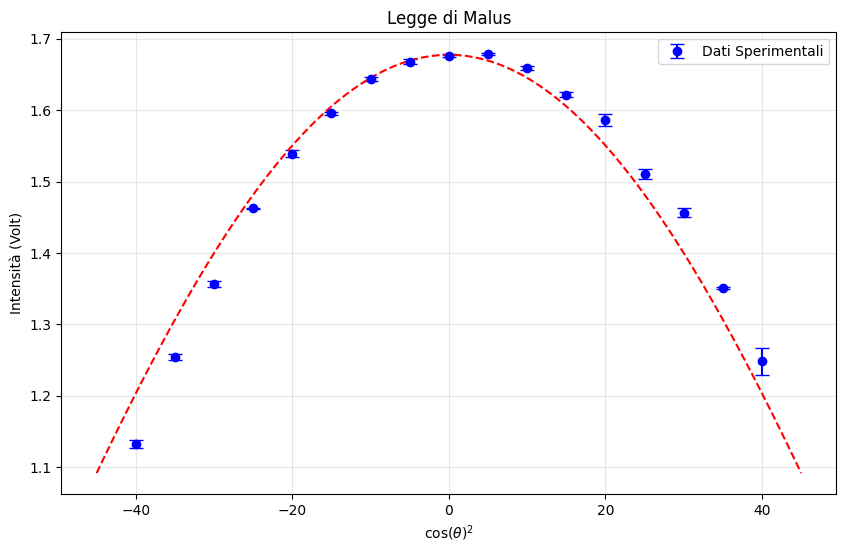

In [5]:
# grafico Legge di Malus
plt.figure(figsize=(10, 6))
plt.errorbar(alfa, I_media, yerr=I_std, 
             fmt='o', label='Dati Sperimentali', color='blue', capsize=5)

#  plot grafico
x_axes = np.linspace(-45, 45, 100)
plt.plot(x_axes, func_fit(x_axes, A_fit, B_fit), '--', color='red')

plt.xlabel('$\\cos(\\theta)^2$')
plt.ylabel('Intensità (Volt)')
plt.title('Legge di Malus')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# calcolo dei valori di y_fit
y_fit = func_fit(alfa, A_fit, B_fit)

# calcolo del chi quadro
chi2 = np.sum(((I_media - y_fit) / I_std) ** 2)
print(f"Chi quadro: {chi2:.2f}")

# calcolo dei gradi di libertà
dof = len(alfa) - len(popt)
print(f"Gradi di libertà: {dof}")

# calcolo del chi quadro ridotto
chi2_red = chi2 / dof
print(f"Chi quadro ridotto: {chi2_red:.2f}")

# calcolo del p-value
p_value = 1 - chi2_dist.cdf(chi2, dof)
print(f"P-value: {p_value:.2f}")

Chi quadro: 1649.14
Gradi di libertà: 15
Chi quadro ridotto: 109.94
P-value: 0.00


GEOMETRIA

In [7]:
# lista intensità
df = pd.read_excel(r"C:\Users\NB05\Desktop\lab 2\microonde\MICROONDE.xlsx", sheet_name="Foglio2", usecols="H:I", skiprows = 3)
df = df.dropna()
I_media_angoli = df.iloc[:, 0].tolist()
I_std_angoli = df.iloc[:, 1].tolist()


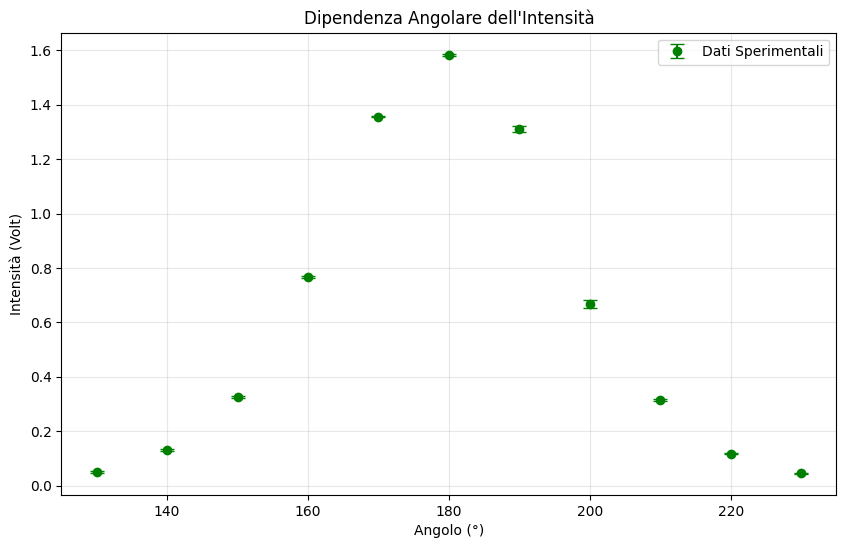

In [8]:
# lista theta 
theta = np.array([130,140, 150, 160, 170, 180,190, 200, 210, 220, 230])

# plot grafico dipendenza angolare dell'intensità
plt.figure(figsize=(10, 6))
plt.errorbar(theta, I_media_angoli, yerr=I_std_angoli, 
             fmt='o', label='Dati Sperimentali', color='green', capsize=5)
plt.xlabel('Angolo (°)')
plt.ylabel('Intensità (Volt)')
plt.title('Dipendenza Angolare dell\'Intensità')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
# funzione di fit per la posizione
def r_fit (x, A, B, C) :
    return (A / (x**2)) + (B / x) + C

In [10]:
# lista intensità
df = pd.read_excel(r"C:\Users\NB05\Desktop\lab 2\microonde\MICROONDE.xlsx", sheet_name="Foglio3")
P_massimi = df["P_massimo "].dropna().tolist()
I_massimo = df["I"].dropna().tolist()
I_massimo_err = [0.002] * len(I_massimo)  # Supponiamo un errore costante di 0.1 Volt per ogni misura

print(len(P_massimi))
print(len(I_massimo))

# sottriamo a ciascuna posizione 16cm che è la posizione dell'emettitore
P_massimi = [p - 16 for p in P_massimi]

51
51


In [34]:
# punti per trovare lambda
P_lambda = []
for i in range(len(P_massimi)):
    if (P_massimi[i] > 69 ) :
            if (P_massimi[i] < 72.5):
                P_lambda.append(P_massimi[i]) 
print(len(P_lambda))
I_lambda = []
for i in range(len(I_massimo)):
    if (I_massimo[i] > 1.53) :
        if (I_massimo [i] < 1.59) :
            I_lambda.append(I_massimo[i]) 
print(len(I_lambda))

17
17


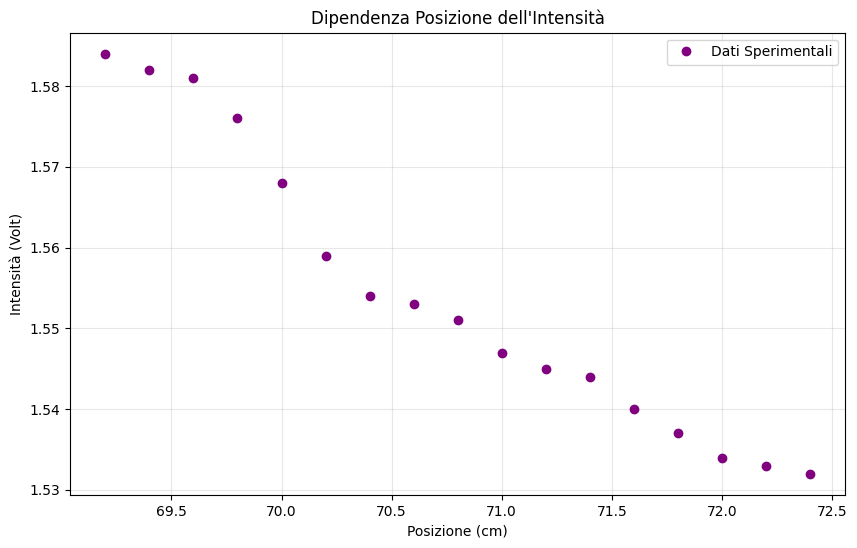

In [32]:
# plot per trovare lambda
plt.figure(figsize=(10, 6))
plt.errorbar(P_lambda, I_lambda, fmt='o', label='Dati Sperimentali', color='purple', capsize=5)
plt.xlabel('Posizione (cm)')
plt.ylabel('Intensità (Volt)')
plt.title('Dipendenza Posizione dell\'Intensità')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

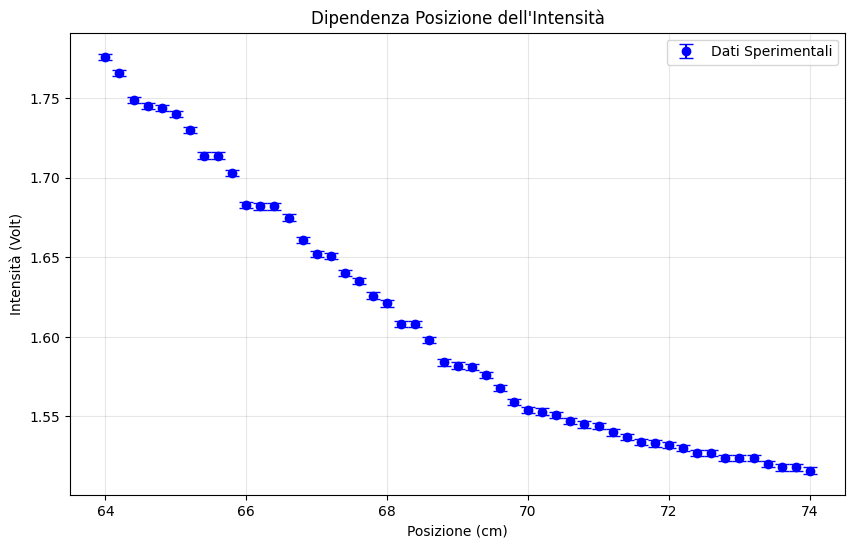

In [26]:
# plot grafico a dispersione dell'intensità in funzione della posizione
plt.figure(figsize=(10, 6))
plt.errorbar(P_massimi, I_massimo, yerr= I_massimo_err, 
             fmt='o', label='Dati Sperimentali', color='blue', capsize=5)
plt.xlabel('Posizione (cm)')
plt.ylabel('Intensità (Volt)')
plt.title('Dipendenza Posizione dell\'Intensità')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
# fit intensità in funzione della posizione
popt, pcov = curve_fit(r_fit, P_massimi, I_massimo, sigma=I_massimo_err)
A_fit = popt[0]
B_fit = popt[1]
C_fit = popt[2]
A_fit_std = np.sqrt(pcov[0][0])
B_fit_std = np.sqrt(pcov[1][1])
C_fit_std = np.sqrt(pcov[2][2])

# stampa dei risultati
print(f"Valore di A: {A_fit:.4f} ± {A_fit_std:.4f}")
print(f"Valore di B: {B_fit:.4f} ± {B_fit_std:.4f}")
print(f"Valore di C: {C_fit:.4f} ± {C_fit_std:.4f}")

Valore di A: 46339.6950 ± 2436.0406
Valore di B: -1221.6619 ± 70.9068
Valore di C: 9.5598 ± 0.5152


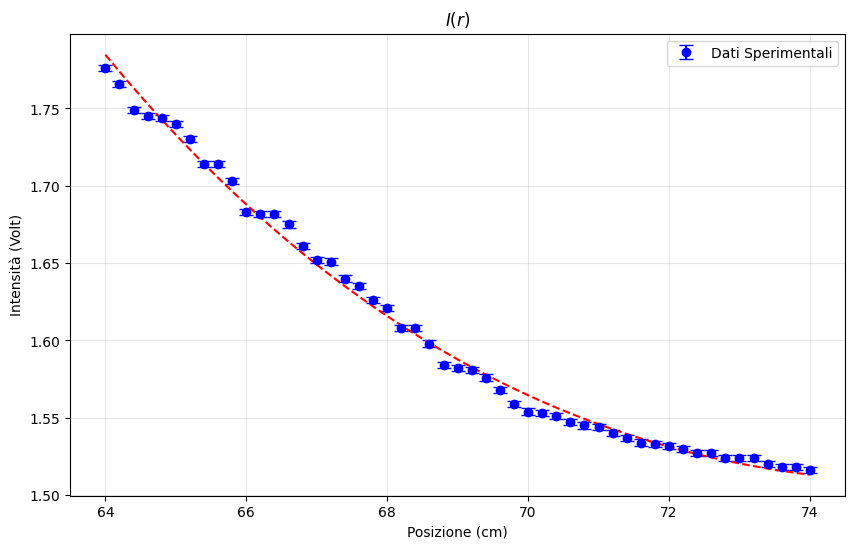

In [13]:
# grafico fit dell'intensità in funzione della posizione
plt.figure(figsize=(10, 6))
plt.errorbar(P_massimi, I_massimo, yerr=I_massimo_err, 
             fmt='o', label='Dati Sperimentali', color='blue', capsize=5)

#  plot grafico
x_axes = np.linspace(np.min(P_massimi), np.max(P_massimi), 1000)
plt.plot(x_axes, r_fit(x_axes, A_fit, B_fit, C_fit), '--', color='red')

plt.xlabel('Posizione (cm)')
plt.ylabel('Intensità (Volt)')
plt.title('$I(r)$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
# calcolo dei valori di y_fit
P_fit = [0] * len(P_massimi)
for i in range(len(P_massimi)):
    P_fit[i] = r_fit(P_massimi[i], A_fit, B_fit, C_fit)

# calcolo del chi quadro
chi2 = 0
for j in range(len(P_massimi)):
    chi2 += ((I_massimo[j] - P_fit[j]) / I_massimo_err[j]) ** 2
print(f"Chi quadro: {chi2:.2f}")

# calcolo dei gradi di libertà
dof = len(P_massimi) - len(popt)
print(f"Gradi di libertà: {dof}")

# calcolo del chi quadro ridotto
chi2_red = chi2 / dof
print(f"Chi quadro ridotto: {chi2_red:.2f}")

# calcolo del p-value
p_value = 1 - chi2_dist.cdf(chi2, dof)
print(f"P-value: {p_value:.2f}")

Chi quadro: 432.45
Gradi di libertà: 48
Chi quadro ridotto: 9.01
P-value: 0.00


In [15]:
# lista intensità totale
df = pd.read_excel(r"C:\Users\NB05\Desktop\lab 2\microonde\MICROONDE.xlsx", sheet_name="Foglio3")
P_max_tot = df["P_max_tot"].dropna().tolist()
I_max_tot = df["I_massimi_tot"].dropna().tolist()
I_max_tot_err = [0.002] * len(I_max_tot)  # Supponiamo un errore costante di 0.1 Volt per ogni misura

print(len(P_max_tot))
print(len(I_max_tot))

# sottriamo a ciascuna posizione 16cm che è la posizione dell'emettitore
P_max_tot = [p - 16 for p in P_max_tot]

67
67


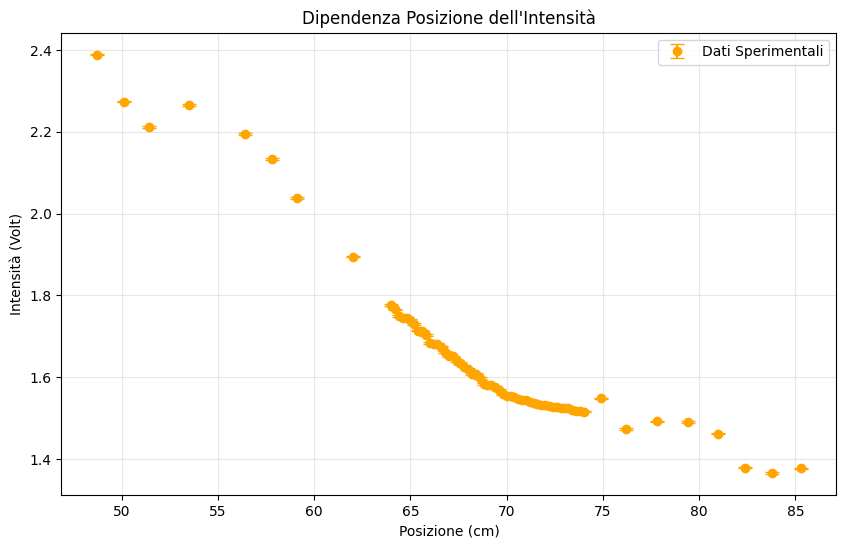

In [16]:
# grafico di dispersione dell'intensità in funzione delle posizioni totali
plt.figure(figsize=(10, 6))
plt.errorbar(P_max_tot, I_max_tot, yerr=I_max_tot_err, 
             fmt='o', label='Dati Sperimentali', color='orange', capsize=5)
plt.xlabel('Posizione (cm)')
plt.ylabel('Intensità (Volt)')
plt.title('Dipendenza Posizione dell\'Intensità')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
# fit intensità in funzione della posizione
popt, pcov = curve_fit(r_fit, P_max_tot, I_max_tot, sigma=I_max_tot_err)
A_fit_max = popt[0]
B_fit_max = popt[1]
C_fit_max = popt[2]
A_fit_max_std = np.sqrt(pcov[0][0])
B_fit_max_std = np.sqrt(pcov[1][1])
C_fit_max_std = np.sqrt(pcov[2][2])

# stampa dei risultati
print(f"Valore di A: {A_fit_max:.4f} ± {A_fit_max_std:.4f}")
print(f"Valore di B: {B_fit_max:.4f} ± {B_fit_max_std:.4f}")
print(f"Valore di C: {C_fit_max:.4f} ± {C_fit_max_std:.4f}")

Valore di A: 3727.3875 ± 1237.8354
Valore di B: 7.9572 ± 39.6125
Valore di C: 0.7204 ± 0.3135


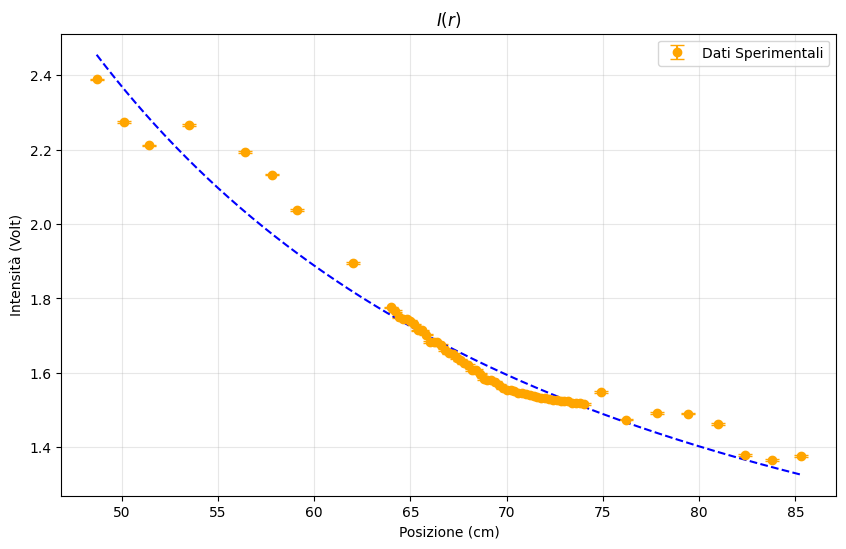

In [18]:
# grafico fit dell'intensità in funzione della posizione
plt.figure(figsize=(10, 6))
plt.errorbar(P_max_tot, I_max_tot, yerr=I_max_tot_err, 
             fmt='o', label='Dati Sperimentali', color='orange', capsize=5)

#  plot grafico
x_axes = np.linspace(np.min(P_max_tot), np.max(P_max_tot), 1000)
plt.plot(x_axes, r_fit(x_axes, A_fit_max, B_fit_max, C_fit_max), '--', color='blue')

plt.xlabel('Posizione (cm)')
plt.ylabel('Intensità (Volt)')
plt.title('$I(r)$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
# calcolo dei valori di y_fit
P_fit_max = [0] * len(P_max_tot)
for i in range(len(P_max_tot)):
    P_fit_max[i] = r_fit(P_max_tot[i], A_fit_max, B_fit_max, C_fit_max)

# calcolo del chi quadro
chi2_max = 0
for j in range(len(P_max_tot)):
    chi2_max += ((I_max_tot[j] - P_fit_max[j]) / I_max_tot_err[j]) ** 2
print(f"Chi quadro: {chi2_max:.2f}")

# calcolo dei gradi di libertà
dof = len(P_max_tot) - len(popt)
print(f"Gradi di libertà: {dof}")

# calcolo del chi quadro ridotto
chi2_red = chi2_max / dof
print(f"Chi quadro ridotto: {chi2_red:.2f}")

# calcolo del p-value
p_value = 1 - chi2_dist.cdf(chi2_max, dof)
print(f"P-value: {p_value:.2f}")

Chi quadro: 35970.29
Gradi di libertà: 64
Chi quadro ridotto: 562.04
P-value: 0.00


ANGOLO DI BREWSTER

In [20]:
def brewster_angle_fit (x, A, B, C) :
    return A*x**2 + B*x + C

In [21]:
# lista medie angoli di bewster
theta_brewster = np.array([227, 227, 228, 228, 228])
theta_brewster_err = [1] * len(theta_brewster)              # Supponiamo un errore costante di 0.5 gradi per ogni misura
theta_brewster_real = [theta - 180 for theta in theta_brewster]
I_max_brewster = np.array([2.904, 2.911, 2.904, 2.913, 2.912])
I_max_brewster_err = [0.002] * len(I_max_brewster)  # Supponiamo un errore costante di 0.1 Volt per ogni misura

# stampiamo i dati
print("Angoli di Brewster (gradi):", theta_brewster_real)

Angoli di Brewster (gradi): [np.int64(47), np.int64(47), np.int64(48), np.int64(48), np.int64(48)]


In [22]:
# fittiamo i dati degli angoli di Brewster
popt, pcov = curve_fit(brewster_angle_fit, theta_brewster_real, I_max_brewster, sigma=theta_brewster_err)
A_fit_brewster = popt[0]
B_fit_brewster = popt[1]
C_fit_brewster = popt[2]
A_fit_brewster_std = np.sqrt(pcov[0][0])
B_fit_brewster_std = np.sqrt(pcov[1][1])
C_fit_brewster_std = np.sqrt(pcov[2][2])

# stampa dei risultati
print(f"Valore di A: {A_fit_brewster:.4f} ± {A_fit_brewster_std:.4f}")
print(f"Valore di B: {B_fit_brewster:.4f} ± {B_fit_brewster_std:.4f}")
print(f"Valore di C: {C_fit_brewster:.4f} ± {C_fit_brewster_std:.4f}")

Valore di A: -40.7695 ± 34319270136.9523
Valore di B: 3873.1073 ± 3260331664824.6553
Valore di C: -91973.2480 ± 77424321106112.3438


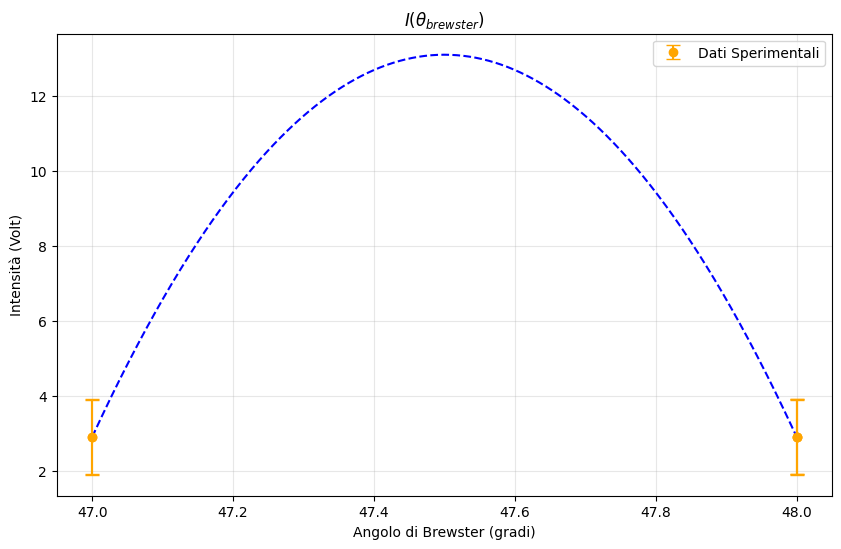

In [23]:
#plottiamo i dati degli angoli di Brewster con il fit
plt.figure(figsize=(10, 6))
plt.errorbar(theta_brewster_real, I_max_brewster, yerr=theta_brewster_err, 
             fmt='o', label='Dati Sperimentali', color='orange', capsize=5)

#  plot grafico
x_axes = np.linspace(np.min(theta_brewster_real), np.max(theta_brewster_real), 1000)
plt.plot(x_axes, brewster_angle_fit(x_axes, A_fit_brewster, B_fit_brewster, C_fit_brewster), '--', color='blue')

plt.xlabel('Angolo di Brewster (gradi)')
plt.ylabel('Intensità (Volt)')
plt.title('$I(\\theta_{brewster})$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
# calcolo dei valori di brewster fit
brewster_fit = [0] * len(I_max_brewster)
for i in range(len(theta_brewster_real)):
    brewster_fit[i] = brewster_angle_fit(theta_brewster_real[i], A_fit_brewster, B_fit_brewster, C_fit_brewster)

# calcolo del chi quadro
chi2_brewster = 0
for j in range(len(I_max_brewster)):
    chi2_brewster += ((I_max_brewster[j] - brewster_fit[j]) / I_max_brewster_err[j]) ** 2
print(f"Chi quadro: {chi2_brewster:.2f}")

# calcolo dei gradi di libertà
dof = len(I_max_brewster) - len(popt)
print(f"Gradi di libertà: {dof}")

# calcolo del chi quadro ridotto
chi2_red = chi2_brewster / dof
print(f"Chi quadro ridotto: {chi2_red:.2f}")

# calcolo del p-value
p_value = 1 - chi2_dist.cdf(chi2_brewster, dof)
print(f"P-value: {p_value:.2f}")

Chi quadro: 18.29
Gradi di libertà: 2
Chi quadro ridotto: 9.15
P-value: 0.00
